In [1]:
from pathlib import Path
import logging

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import ras_commander
from ras_commander import (
    HdfResultsPlan,
    RasCalibrate,
    RasCmdr,
    RasExamples,
    extract_steady_profile_modeled,
    extract_steady_profile_observations,
    init_ras_project,
    make_steady_profile_calibration_points,
    make_xsec_mannings_apply_fn,
)

logging.disable(logging.CRITICAL)

print(f"ras-commander {ras_commander.__version__}")

ras-commander 0.96.1


## Development Mode

When running this notebook from a source checkout instead of an installed package, start Jupyter from the repository root or add the repository root to `PYTHONPATH` before launching Jupyter. Generated example projects and run outputs are written under `working/`.

# Steady Flow Calibration Helpers

This notebook demonstrates the steady-profile calibration helpers on a real HEC-RAS example project. It uses `RasExamples` to extract a small 1D steady-flow model, computes a steady plan HDF, converts steady profile WSE rows into `CalibrationPoint` objects, and applies a cross-section Manning's n adjustment with `make_xsec_mannings_apply_fn()`.

In [2]:
def find_repo_root(start):
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "ras_commander").exists():
            return candidate
    return start

REPO_ROOT = find_repo_root(Path.cwd())
WORK_ROOT = REPO_ROOT / "working" / "steady_flow_calibration"
PROJECT_NAME = "Chapter 4 Example Data"
PLAN_NUMBER = "01"
RAS_EXE = Path(r"C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe")
ras_exe_arg = str(RAS_EXE) if RAS_EXE.exists() else "7.0"

WORK_ROOT.mkdir(parents=True, exist_ok=True)
project_path = RasExamples.extract_project(
    PROJECT_NAME,
    output_path=WORK_ROOT,
    suffix="clb308",
)
ras_project = init_ras_project(project_path, ras_exe_arg)

plan_overview = ras_project.plan_df[
    ["plan_number", "Plan Title", "flow_type", "Geom File", "Flow File"]
].copy()
display(plan_overview)
print(f"Repository root: {REPO_ROOT}")
print(f"Project path: {project_path}")
print(f"HEC-RAS executable: {ras_exe_arg}")

,plan_number,Plan Title,flow_type,Geom File,Flow File
0,01,Existing Conditions Run,Steady,01,01


Repository root: C:\GH\symphony-workspaces\ras-commander\CLB-308
Project path: C:\GH\symphony-workspaces\ras-commander\CLB-308\working\steady_flow_calibration\Chapter 4 Example Data_clb308
HEC-RAS executable: C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe


In [3]:
compute_result = RasCmdr.compute_plan(
    PLAN_NUMBER,
    ras_object=ras_project,
    num_cores=1,
    verify=True,
    force_rerun=True,
)
assert compute_result, "HEC-RAS plan execution failed"

plan_hdf = project_path / f"{ras_project.project_name}.p{PLAN_NUMBER}.hdf"
assert plan_hdf.exists(), plan_hdf

profile_names = HdfResultsPlan.get_steady_profile_names(plan_hdf)
print(f"Computed plan HDF: {plan_hdf}")
print(f"Steady profiles: {profile_names}")

Computed plan HDF: C:\GH\symphony-workspaces\ras-commander\CLB-308\working\steady_flow_calibration\Chapter 4 Example Data_clb308\EX1.p01.hdf
Steady profiles: ['10 yr', '50 yr', '100 yr']


## Observed WSE Rows

For this repeatable example, observed WSE is synthetic calibration data derived from the known-good computed plan HDF. The rows keep explicit `river`, `reach`, `station`, and `profile` fields so station/profile matching is transparent.

In [4]:
all_observations = extract_steady_profile_observations(plan_hdf)
observations = all_observations[
    (all_observations["river"] == "Butte Cr.")
    & (all_observations["reach"] == "Tributary")
    & (all_observations["station"].isin(["0.2", "0.1"]))
].copy().reset_index(drop=True)
observations["station_numeric"] = observations["station"].astype(float)

display(observations[["river", "reach", "station", "profile", "observed"]])
print(
    f"Observation rows: {len(observations)} across "
    f"{observations['profile'].nunique()} steady profiles"
)

,river,reach,station,profile,observed
0,Butte Cr.,Tributary,0.2,10 yr,76.581253
1,Butte Cr.,Tributary,0.1,10 yr,76.193848
2,Butte Cr.,Tributary,0.2,50 yr,82.302467
3,Butte Cr.,Tributary,0.1,50 yr,81.718552
4,Butte Cr.,Tributary,0.2,100 yr,86.678116
5,Butte Cr.,Tributary,0.1,100 yr,86.210762


Observation rows: 6 across 3 steady profiles


In [5]:
calibration_points = make_steady_profile_calibration_points(
    observations,
    station_tolerance=0.001,
)

point_preview = pd.DataFrame(
    [
        {
            "name": point.name,
            "profile": point.profile_name,
            "river": point.river,
            "reach": point.reach,
            "station": point.station,
            "observed": point.observed,
            "station_tolerance": point.station_tolerance,
        }
        for point in calibration_points
    ]
)
display(point_preview)
print(f"CalibrationPoint count: {len(calibration_points)}")

,name,profile,river,reach,station,observed,station_tolerance
0,10 yr Butte Cr./Tributary/0.2,10 yr,Butte Cr.,Tributary,0.2,76.581253,0.001
1,10 yr Butte Cr./Tributary/0.1,10 yr,Butte Cr.,Tributary,0.1,76.193848,0.001
2,50 yr Butte Cr./Tributary/0.2,50 yr,Butte Cr.,Tributary,0.2,82.302467,0.001
3,50 yr Butte Cr./Tributary/0.1,50 yr,Butte Cr.,Tributary,0.1,81.718552,0.001
4,100 yr Butte Cr./Tributary/0.2,100 yr,Butte Cr.,Tributary,0.2,86.678116,0.001
5,100 yr Butte Cr./Tributary/0.1,100 yr,Butte Cr.,Tributary,0.1,86.210762,0.001


CalibrationPoint count: 6


## Modeled WSE Extraction

`extract_steady_profile_modeled()` reads modeled WSE values from the computed steady plan HDF and matches each `CalibrationPoint` by river, reach, station, and steady profile.

In [6]:
def comparison_from_hdf(hdf_path, run_label):
    rows = []
    for point in calibration_points:
        modeled = extract_steady_profile_modeled(point, hdf_path)
        rows.append(
            {
                "run": run_label,
                "profile": point.profile_name,
                "river": point.river,
                "reach": point.reach,
                "station": point.station,
                "station_numeric": float(point.station),
                "observed": point.observed,
                "modeled": modeled,
                "residual": point.observed - modeled,
            }
        )
    return pd.DataFrame(rows)

baseline_comparison = comparison_from_hdf(plan_hdf, "source model")
baseline_rmse = (baseline_comparison["residual"].pow(2).mean()) ** 0.5

display(baseline_comparison)
print(f"Baseline RMSE: {baseline_rmse:.6f} ft")

,run,profile,river,reach,station,station_numeric,observed,modeled,residual
0,source model,10 yr,Butte Cr.,Tributary,0.2,0.2,76.581253,76.581253,0.0
1,source model,10 yr,Butte Cr.,Tributary,0.1,0.1,76.193848,76.193848,0.0
2,source model,50 yr,Butte Cr.,Tributary,0.2,0.2,82.302467,82.302467,0.0
3,source model,50 yr,Butte Cr.,Tributary,0.1,0.1,81.718552,81.718552,0.0
4,source model,100 yr,Butte Cr.,Tributary,0.2,0.2,86.678116,86.678116,0.0
5,source model,100 yr,Butte Cr.,Tributary,0.1,0.1,86.210762,86.210762,0.0


Baseline RMSE: 0.000000 ft


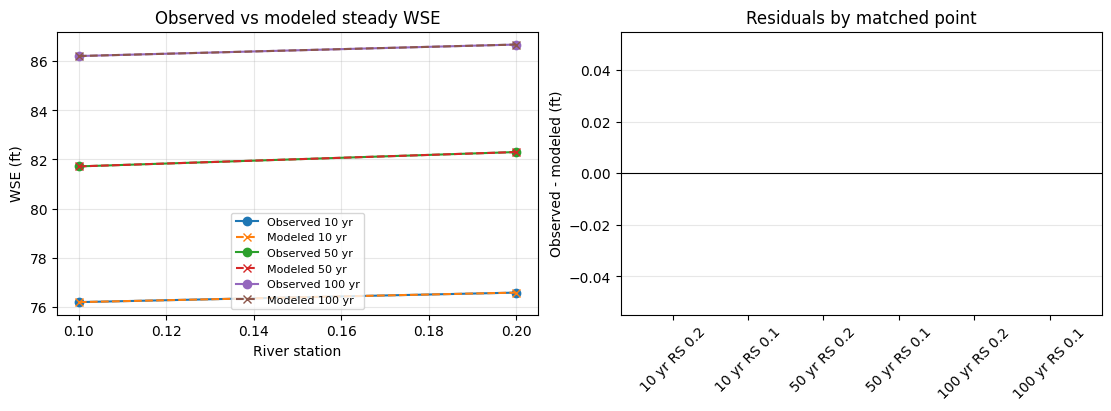

In [7]:
def plot_observed_vs_modeled(comparison, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

    for profile, profile_df in comparison.groupby("profile", sort=False):
        ordered = profile_df.sort_values("station_numeric")
        axes[0].plot(
            ordered["station_numeric"],
            ordered["observed"],
            marker="o",
            linestyle="-",
            label=f"Observed {profile}",
        )
        axes[0].plot(
            ordered["station_numeric"],
            ordered["modeled"],
            marker="x",
            linestyle="--",
            label=f"Modeled {profile}",
        )

    axes[0].set_xlabel("River station")
    axes[0].set_ylabel("WSE (ft)")
    axes[0].set_title(title)
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    residual_labels = comparison["profile"] + " RS " + comparison["station"]
    axes[1].bar(residual_labels, comparison["residual"])
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_ylabel("Observed - modeled (ft)")
    axes[1].set_title("Residuals by matched point")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].grid(True, axis="y", alpha=0.3)
    plt.show()

plot_observed_vs_modeled(baseline_comparison, "Observed vs modeled steady WSE")

## Manning's n Adjustment

The apply function below targets the channel Manning's n at Butte Cr. / Tributary / RS 0.2. It clones the active geometry before editing it, removes stale compiled geometry HDF output, then `RasCalibrate.evaluate_single()` recomputes the plan through `RasCmdr.compute_plan()`.

In [8]:
apply_fn = make_xsec_mannings_apply_fn(
    {
        "n_channel": {
            "river": "Butte Cr.",
            "reach": "Tributary",
            "station": "0.2",
            "subsection": "Channel",
        }
    },
    clone_geometry=True,
)

print("Created Manning's n apply_fn for Butte Cr. / Tributary / RS 0.2 channel")

Created Manning's n apply_fn for Butte Cr. / Tributary / RS 0.2 channel


In [9]:
def comparison_from_result(result, run_label, n_channel):
    rows = []
    for point, point_result in zip(calibration_points, result["point_results"]):
        modeled = point_result["modeled"]
        rows.append(
            {
                "run": run_label,
                "n_channel": n_channel,
                "profile": point.profile_name,
                "river": point.river,
                "reach": point.reach,
                "station": point.station,
                "station_numeric": float(point.station),
                "observed": point.observed,
                "modeled": modeled,
                "residual": point.observed - modeled,
            }
        )
    return pd.DataFrame(rows)

before_result = RasCalibrate.evaluate_single(
    PLAN_NUMBER,
    {"n_channel": 0.12},
    apply_fn,
    calibration_points,
    metric="rmse",
    num_cores=1,
    force_geompre=True,
    ras_object=ras_project,
)
after_result = RasCalibrate.evaluate_single(
    PLAN_NUMBER,
    {"n_channel": 0.04},
    apply_fn,
    calibration_points,
    metric="rmse",
    num_cores=1,
    force_geompre=True,
    ras_object=ras_project,
)

before_comparison = comparison_from_result(before_result, "roughness too high", 0.12)
after_comparison = comparison_from_result(after_result, "restored calibration", 0.04)
calibration_comparison = pd.concat(
    [before_comparison, after_comparison],
    ignore_index=True,
)
summary = pd.DataFrame(
    [
        {
            "run": "roughness too high",
            "n_channel": 0.12,
            "success": before_result["success"],
            "rmse_ft": before_result["overall_objective"],
        },
        {
            "run": "restored calibration",
            "n_channel": 0.04,
            "success": after_result["success"],
            "rmse_ft": after_result["overall_objective"],
        },
    ]
)

display(summary)
display(calibration_comparison)

,run,n_channel,success,rmse_ft
0,roughness too high,0.12,True,0.203709
1,restored calibration,0.04,True,0.000000


,run,n_channel,profile,river,reach,station,station_numeric,observed,modeled,residual
0,roughness too high,0.12,10 yr,Butte Cr.,Tributary,0.2,0.2,76.581253,77.003128,-0.421875
1,roughness too high,0.12,10 yr,Butte Cr.,Tributary,0.1,0.1,76.193848,76.193848,0.000000
2,roughness too high,0.12,50 yr,Butte Cr.,Tributary,0.2,0.2,82.302467,82.837036,-0.534569
3,roughness too high,0.12,50 yr,Butte Cr.,Tributary,0.1,0.1,81.718552,81.718071,0.000481
4,roughness too high,0.12,100 yr,Butte Cr.,Tributary,0.2,0.2,86.678116,86.943428,-0.265312
5,roughness too high,0.12,100 yr,Butte Cr.,Tributary,0.1,0.1,86.210762,86.210777,-0.000015
6,restored calibration,0.04,10 yr,Butte Cr.,Tributary,0.2,0.2,76.581253,76.581253,0.000000
7,restored calibration,0.04,10 yr,Butte Cr.,Tributary,0.1,0.1,76.193848,76.193848,0.000000
8,restored calibration,0.04,50 yr,Butte Cr.,Tributary,0.2,0.2,82.302467,82.302467,0.000000
9,restored calibration,0.04,50 yr,Butte Cr.,Tributary,0.1,0.1,81.718552,81.718552,0.000000


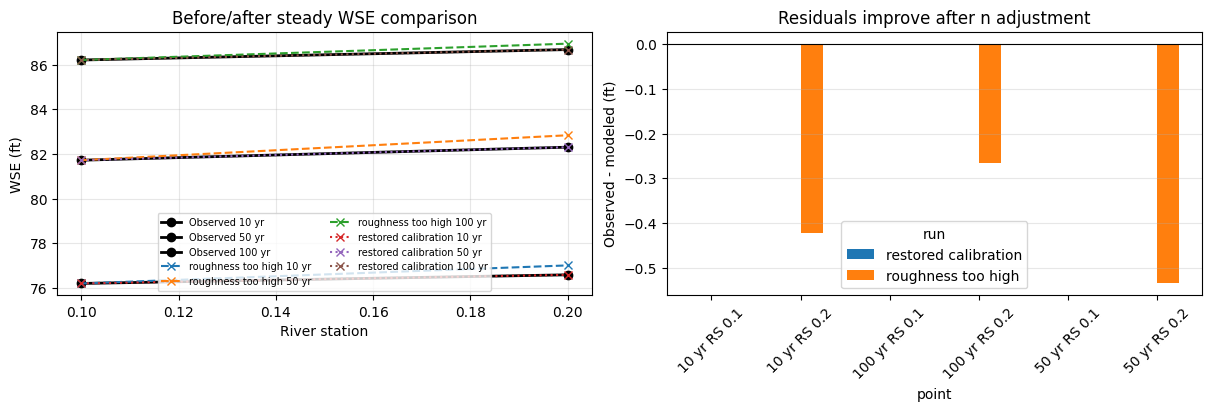

RMSE improved from 0.203709 ft to 0.000000 ft


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

for profile, observed_profile in observations.groupby("profile", sort=False):
    ordered_observed = observed_profile.sort_values("station_numeric")
    axes[0].plot(
        ordered_observed["station_numeric"],
        ordered_observed["observed"],
        color="black",
        marker="o",
        linewidth=2,
        label=f"Observed {profile}",
    )

for (run, profile), modeled_profile in calibration_comparison.groupby(["run", "profile"], sort=False):
    ordered_modeled = modeled_profile.sort_values("station_numeric")
    linestyle = "--" if run == "roughness too high" else ":"
    axes[0].plot(
        ordered_modeled["station_numeric"],
        ordered_modeled["modeled"],
        marker="x",
        linestyle=linestyle,
        label=f"{run} {profile}",
    )

axes[0].set_xlabel("River station")
axes[0].set_ylabel("WSE (ft)")
axes[0].set_title("Before/after steady WSE comparison")
axes[0].legend(fontsize=7, ncols=2)
axes[0].grid(True, alpha=0.3)

residual_table = calibration_comparison.copy()
residual_table["point"] = residual_table["profile"] + " RS " + residual_table["station"]
residual_pivot = residual_table.pivot(index="point", columns="run", values="residual")
residual_pivot.plot(kind="bar", ax=axes[1])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Observed - modeled (ft)")
axes[1].set_title("Residuals improve after n adjustment")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, axis="y", alpha=0.3)
plt.show()

print(
    "RMSE improved from "
    f"{before_result['overall_objective']:.6f} ft to "
    f"{after_result['overall_objective']:.6f} ft"
)

In [11]:
assert before_result["success"] and after_result["success"]
assert after_result["overall_objective"] < before_result["overall_objective"]
assert len(calibration_points) == 6

print("Executed steady-profile calibration workflow against a real RasExamples project.")
print(f"Observed profiles: {sorted(observations['profile'].unique())}")
print(f"Matched stations: {sorted(observations['station'].unique())}")
print(f"Final plan HDF: {plan_hdf}")

Executed steady-profile calibration workflow against a real RasExamples project.
Observed profiles: ['10 yr', '100 yr', '50 yr']
Matched stations: ['0.1', '0.2']
Final plan HDF: C:\GH\symphony-workspaces\ras-commander\CLB-308\working\steady_flow_calibration\Chapter 4 Example Data_clb308\EX1.p01.hdf
